# Классы Dataset и Dataloader

In [6]:
import os
import json
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms.v2 as tfs

## Преобразование MNIST

In [2]:
transform = tfs.ToPILImage()

mnist_train = torchvision.datasets.MNIST(r'.\datasets\mnist', download=True, train=True)
mnist_test = torchvision.datasets.MNIST(r'.\datasets\mnist', download=True, train=False)

dir_out = 'dataset'
file_format = 'format.json'
train_data = {'dir': "train", 'data': mnist_train}
test_data = {'dir': "test", 'data': mnist_test}

if not os.path.exists(dir_out):
    os.mkdir(dir_out)

    for info in (train_data, test_data):
        os.mkdir(os.path.join(dir_out, info['dir']))

        for i in range(10):
            os.mkdir(os.path.join(dir_out, info['dir'], f"class_{i}"))


for info in (train_data, test_data):
    for i in range(10):
        path = os.path.join(dir_out, info['dir'], f"class_{i}")
        cls = info['data'].data[info['data'].targets == i]

        for n, x in enumerate(cls):
            x = transform(x)
            x.save(os.path.join(path, f"img_{n}.png"), "png")

targets = dict()
for i in range(10):
    targets[f'class_{i}'] = i

fp = open(os.path.join(dir_out, file_format), "w")
json.dump(targets, fp)
fp.close()

KeyboardInterrupt: 

## Считывание CSV

In [ ]:
# # Создание csv файла
# data = {
#     'id': [0, 1, 2, 3],
#     'feature1': [0.5, 0.6, 0.9, 0.4],
#     'feature2': [1.2, 1.1, 1.8, 0.9],
#     'label': [1, 0, 1, 0]
# }

# df = pd.DataFrame(data)
# df.to_csv('../../../datasets/data.csv', index=False)

In [7]:
class CSVDataset(Dataset):
    def __init__(self, file_path, transform=None):
        self.data = pd.read_csv(file_path)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        features = torch.tensor([row['feature1'], row['feature2']], dtype=torch.float32)
        label = torch.tensor(row['label'], dtype=torch.long)

        return features, label

In [8]:
dataset = CSVDataset('../../../datasets/data.csv')
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)

for features, labels in dataloader:
    print(features, labels)

tensor([[0.9000, 1.8000],
        [0.6000, 1.1000]]) tensor([1, 0])
tensor([[0.5000, 1.2000],
        [0.4000, 0.9000]]) tensor([1, 0])


tensor(-3.7000) tensor(7.6473) 100


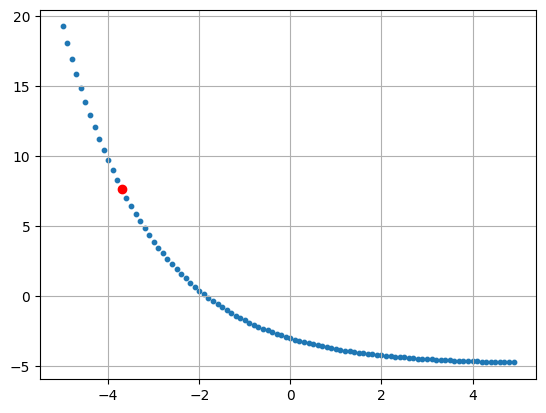

In [12]:
import torch
import torch.nn as nn
import torch.utils.data as data

class FuncDataset(data.Dataset):
    
    def __init__(self):
        self.func = lambda x: 2 * torch.exp(-x / 2) + 0.2 * torch.sin(x / 10) - 5
        self.coord_x = torch.arange(-5, 5, 0.1)
        self.coord_y = self.func(self.coord_x)

    def __len__(self):
        return len(self.coord_x)
    
    def __getitem__(self, idx):
        return self.coord_x[idx], self.coord_y[idx]


d_train = FuncDataset()

x13, y13 = d_train[13]
total = len(d_train)

print(x13, y13, total)

# График
import torch.nn as nn
import matplotlib.pyplot as plt

plt.scatter(d_train.coord_x.numpy(), d_train.coord_y.numpy(), s=10)
plt.scatter(x13.numpy(), y13.numpy(), c='r')
plt.grid()
plt.show()

In [14]:
import torch
import torch.nn as nn
import torch.utils.data as data

class ClassDataset(data.Dataset):
    
    def __init__(self):
        self.data_x = torch.tensor([(5.3, 2.3), (5.7, 2.5), (4.0, 1.0), (5.6, 2.4), (4.5, 1.5), (5.4, 2.3), (4.8, 1.8), (4.5, 1.5), (5.1, 1.5), (6.1, 2.3), (5.1, 1.9), (4.0, 1.2), (5.2, 2.0), (3.9, 1.4), (4.2, 1.2), (4.7, 1.5), (4.8, 1.8), (3.6, 1.3), (4.6, 1.4), (4.5, 1.7), (3.0, 1.1), (4.3, 1.3), (4.5, 1.3), (5.5, 2.1), (3.5, 1.0), (5.6, 2.2), (4.2, 1.5), (5.8, 1.8), (5.5, 1.8), (5.7, 2.3), (6.4, 2.0), (5.0, 1.7), (6.7, 2.0), (4.0, 1.3), (4.4, 1.4), (4.5, 1.5), (5.6, 2.4), (5.8, 1.6), (4.6, 1.3), (4.1, 1.3), (5.1, 2.3), (5.2, 2.3), (5.6, 1.4), (5.1, 1.8), (4.9, 1.5), (6.7, 2.2), (4.4, 1.3), (3.9, 1.1), (6.3, 1.8), (6.0, 1.8), (4.5, 1.6), (6.6, 2.1), (4.1, 1.3), (4.5, 1.5), (6.1, 2.5), (4.1, 1.0), (4.4, 1.2), (5.4, 2.1), (5.0, 1.5), (5.0, 2.0), (4.9, 1.5), (5.9, 2.1), (4.3, 1.3), (4.0, 1.3), (4.9, 2.0), (4.9, 1.8), (4.0, 1.3), (5.5, 1.8), (3.7, 1.0), (6.9, 2.3), (5.7, 2.1), (5.3, 1.9), (4.4, 1.4), (5.6, 1.8), (3.3, 1.0), (4.8, 1.8), (6.0, 2.5), (5.9, 2.3), (4.9, 1.8), (3.3, 1.0), (3.9, 1.2), (5.6, 2.1), (5.8, 2.2), (3.8, 1.1), (3.5, 1.0), (4.5, 1.5), (5.1, 1.9), (4.7, 1.4), (5.1, 1.6), (5.1, 2.0), (4.8, 1.4), (5.0, 1.9), (5.1, 2.4), (4.6, 1.5), (6.1, 1.9), (4.7, 1.6), (4.7, 1.4), (4.7, 1.2), (4.2, 1.3), (4.2, 1.3)])
        self.data_y = torch.tensor([1, 1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1])
    
    def __len__(self):
        return len(self.data_x)
    
    def __getitem__(self, idx):
        return self.data_x[idx], self.data_y[idx]

d_train = ClassDataset()
train_data = data.DataLoader(d_train, batch_size=12, shuffle=True, drop_last=True)

data_sum = 0
for data_x, _ in train_data:
    data_sum += data_x

print(data_sum)

tensor([[40.2000, 13.6000],
        [37.3000, 12.2000],
        [39.1000, 14.7000],
        [40.7000, 13.3000],
        [36.9000, 12.2000],
        [38.3000, 12.8000],
        [37.1000, 12.6000],
        [39.1000, 13.2000],
        [41.0000, 13.1000],
        [43.5000, 16.3000],
        [41.0000, 14.2000],
        [37.9000, 13.6000]])


In [17]:
import torch
import torch.nn as nn
import torch.utils.data as data

class LinnerudDataset(data.Dataset):
    
    def __init__(self):
        self.data_x = torch.tensor([[5.0, 162.0, 60.0], [2.0, 110.0, 60.0], [12.0, 101.0, 101.0], [12.0, 105.0, 37.0], [13.0, 155.0, 58.0], [4.0, 101.0, 42.0], [8.0, 101.0, 38.0], [6.0, 125.0, 40.0], [15.0, 200.0, 40.0], [17.0, 251.0, 250.0], [17.0, 120.0, 38.0], [13.0, 210.0, 115.0], [14.0, 215.0, 105.0], [1.0, 50.0, 50.0], [6.0, 70.0, 31.0], [12.0, 210.0, 120.0], [4.0, 60.0, 25.0], [11.0, 230.0, 80.0], [15.0, 225.0, 73.0], [2.0, 110.0, 43.0]])
        self.target = torch.tensor([[191.,  36.,  50.], [189.,  37.,  52.], [193.,  38.,  58.], [162.,  35.,  62.], [189.,  35.,  46.], [182.,  36.,  56.], [211.,  38.,  56.], [167.,  34.,  60.], [176.,  31.,  74.], [154.,  33.,  56.], [169.,  34.,  50.], [166.,  33.,  52.], [154.,  34.,  64.], [247.,  46.,  50.], [193.,  36.,  46.], [202.,  37.,  62.], [176.,  37.,  54.], [157.,  32.,  52.], [156.,  33.,  54.], [138.,  33.,  68.]])

    def __getitem__(self, item):
        return self.data_x[item], self.target[item]
    
    def __len__(self):
        return len(self.data_x)
    
d_train = LinnerudDataset()

train_data = data.DataLoader(d_train, batch_size=8, shuffle=False)

it = iter(train_data)
x, y = next(it)
print(x, y)

tensor([[  5., 162.,  60.],
        [  2., 110.,  60.],
        [ 12., 101., 101.],
        [ 12., 105.,  37.],
        [ 13., 155.,  58.],
        [  4., 101.,  42.],
        [  8., 101.,  38.],
        [  6., 125.,  40.]]) tensor([[191.,  36.,  50.],
        [189.,  37.,  52.],
        [193.,  38.,  58.],
        [162.,  35.,  62.],
        [189.,  35.,  46.],
        [182.,  36.,  56.],
        [211.,  38.,  56.],
        [167.,  34.,  60.]])


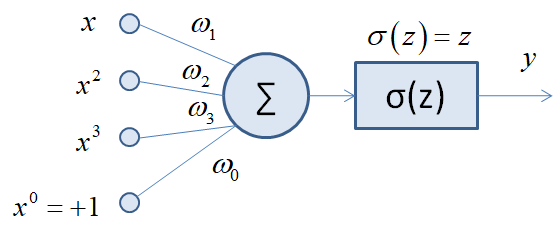



на интервале [-5; 5]. 

In [8]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim


class FuncDataset(data.Dataset):
    def __init__(self):
        _x = torch.arange(-5, 5, 0.1)
        func = lambda x: torch.sin(2 * x) + 0.2 * torch.cos(10 * x) + 0.1 * torch.pow(x, 2)
        self.data = _x
        self.target = func(self.data) # значения функции в точках _x
        self.length = len(self.data) # размер обучающей выборки

    def __getitem__(self, item):
        # возврат образа по индексу item в виде кортежа: (данные, целевое значение)
        return self.data[item], self.target[item]

    def __len__(self):
        # возврат размера выборки
        return self.length


class FuncModel(nn.Module):
    def __init__(self):
        super().__init__()
        # модель однослойной полносвязной нейронной сети:
        # 1-й слой: число входов 3 (x, x^2, x^3), число нейронов 1
        self.layer1 = nn.Linear(3, 1)

    def forward(self, x):
        xx = torch.empty(x.size(0), 3)
        xx[:, 0] = x
        xx[:, 1] = x ** 2
        xx[:, 2] = x ** 3
        y = self.layer1(xx)
        return y


torch.manual_seed(1)

# создать модель FuncModel
model = FuncModel()
# перевести модель в режим обучения
model.train()

epochs = 20 # число эпох обучения
batch_size = 8 # размер батча

d_train = FuncDataset() # создать объект класса FuncDataset
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True) # создать объект класса DataLoader с размером пакетов batch_size и перемешиванием образов выборки

optimizer = optim.Adam(params=model.parameters(), lr=0.01) # создать оптимизатор Adam для обучения модели с шагом обучения 0.01
loss_func = nn.MSELoss() # создать функцию потерь с помощью класса MSELoss

for _e in range(epochs): # итерации по эпохам
    for x_train, y_train in train_data:
        predict = model(x_train) # вычислить прогноз модели для данных x_train
        loss = loss_func(predict.squeeze(), y_train) # вычислить значение функции потерь

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# перевести модель в режим эксплуатации
model.eval()
# выполнить прогноз модели по всем данным выборки (d_train.data)
predict = model(d_train.data)
Q = loss_func(predict.squeeze(), d_train.target).item() # вычислить потери с помощью loss_func по всем данным выборки; значение Q сохранить в виде вещественного числа

print(Q)

0.5361676216125488


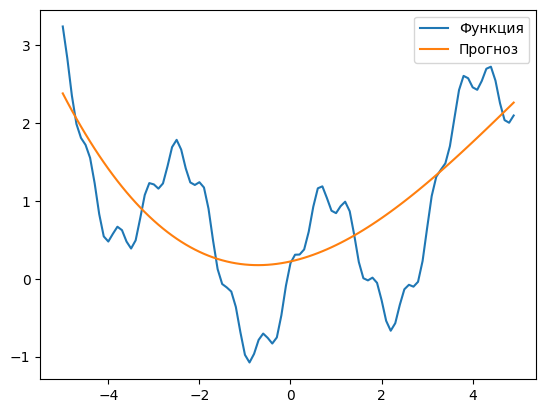

In [13]:
import matplotlib.pyplot as plt

plt.plot(d_train.data, d_train.target, label='Функция')
plt.plot(d_train.data, predict.detach(), label='Прогноз')
plt.legend()
plt.show()

In [19]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

class FuncDataset(data.Dataset):
    def __init__(self):
        _range = torch.arange(-3, 3, 0.1)
        self.data = torch.tensor([(_x, _y) for _x in _range for _y in _range])
        self.target = self._func(self.data)
        self.length = len(self.data) # размер обучающей выборки

    @staticmethod
    def _func(coord):
        _x, _y = coord[:, 0], coord[:, 1]
        return torch.sin(2 * _x) * torch.cos(3 * _y) + 0.2 * torch.cos(10 * _x) * torch.sin(8 * _x) + 0.1 * _x ** 2 + 0.1 * _y ** 2

    def __getitem__(self, item):
        # возврат образа по индексу item в виде кортежа: (данные, целевое значение)
        return self.data[item], self.target[item]

    def __len__(self):
        # возврат размера выборки
        return self.length


class FuncModel(nn.Module):
    def __init__(self):
        super().__init__()
        # модель однослойной полносвязной нейронной сети:
        # 1-й слой: число входов 6 (x, x^2, x^3, y, y^2, y^3), число нейронов 1
        self.layer1 = nn.Linear(6, 1)

    def forward(self, coord):
        x, y = coord[:, 0], coord[:, 1]
        x.unsqueeze_(-1)
        y.unsqueeze_(-1)

        xx = torch.empty(coord.size(0), 6)
        xx[:, :3] = torch.cat([x, x ** 2, x ** 3], dim=1)
        xx[:, 3:] = torch.cat([y, y ** 2, y ** 3], dim=1)
        y = self.layer1(xx)
        return y

# здесь продолжайте программу
epochs = 20
batch_size = 16
lr = 0.01

d_train = FuncDataset()
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)

model = FuncModel()
optimizer = optim.RMSprop(params=model.parameters(), lr=lr)
loss_func = nn.MSELoss()

model.train()

for _e in range(epochs):
    for x_train, y_train in train_data:
        predict = model(x_train)
        loss = loss_func(predict.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()

predict = model(d_train.data)
Q = loss_func(predict.squeeze(), d_train.target).item()
Q

0.2780715823173523

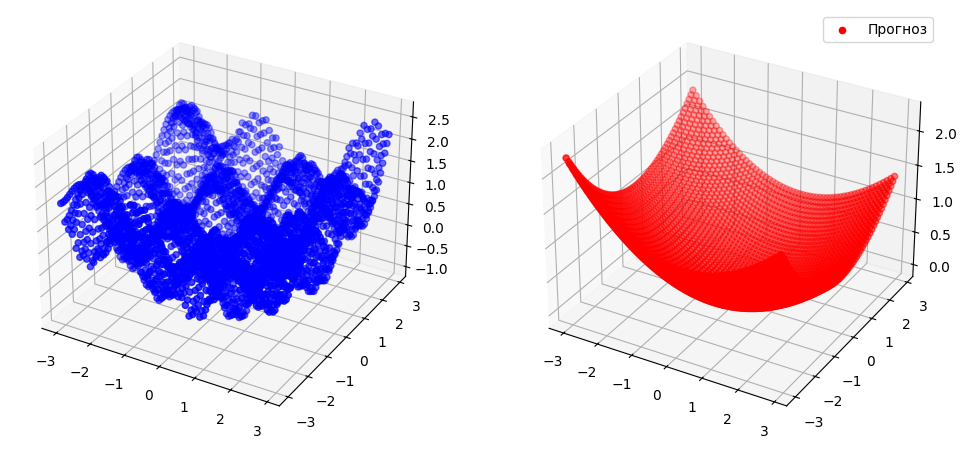

In [22]:
import matplotlib.pyplot as plt

x = d_train.data[:, 0]
y = d_train.data[:, 1]

z = d_train.target
z_pred = predict.data.squeeze()

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x, y, z, c='b', label='Функция')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(x, y, z_pred, c='r', label='Прогноз')

plt.legend()
plt.show()

In [25]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_diabetes

class Dataset(data.Dataset):
    def __init__(self):
        super().__init__()
        diabetes = load_diabetes()
        self._global_var_data_x = torch.tensor(diabetes.data, dtype=torch.float32)
        self._global_var_target = torch.tensor(diabetes.target, dtype=torch.float32)

        self.data = self._global_var_data_x
        self.target = self._global_var_target
        self.length = len(self._global_var_data_x)

    def __getitem__(self, index):
        return self.data[index], self.target[index]
    
    def __len__(self):
        return self.length
    

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(10, 64)
        self.layer2 = nn.Linear(64, 1)

    def forward(self, coord):
        x = self.layer1(coord).tanh()
        x = self.layer2(x)
        return x
    
epochs = 10
lr = 0.01
batch_size = 8

d_train = Dataset()
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)

model = Model()
optimizer = optim.RMSprop(params=model.parameters(), lr=lr)
loss_func = nn.MSELoss()

model.train()

for _e in range(epochs):
    for x_train, y_train in train_data:
        predict = model(x_train)
        loss = loss_func(predict.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()

predict = model(d_train.data)
Q = loss_func(predict.squeeze(), d_train.target).item()
Q

3449.214111328125

In [30]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim


class Dataset(data.Dataset):
    def __init__(self):
        super().__init__()
        _x = torch.arange(-6, 6, 0.1)

        self.data = torch.tensor(_x)
        self.target = self._func(self.data)
        self.length = len(self.data)

    @staticmethod
    def _func(t):
        return 0.5 * t + torch.sin(2 * t) - 0.1 * torch.exp(t / 2) - 12.5

    def __getitem__(self, index):
        return self.data[index], self.target[index]
    
    def __len__(self):
        return self.length


class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(3, 1)

    def forward(self, x):
        xx = torch.empty(x.size(0), 3)
        xx[:, 0] = x
        xx[:, 1] = x ** 2
        xx[:, 2] = x ** 3
        y = self.layer1(xx)
        return y
    
epochs = 20
batch_size = 10
lr = 0.1

d_train = Dataset()
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)

model = Model()
optimizer = optim.RMSprop(params=model.parameters(), lr=lr)
loss_func = nn.MSELoss()

model.train()

for _e in range(epochs):
    for x_train, y_train in train_data:
        predict = model(x_train)
        loss = loss_func(predict.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()

predict = model(d_train.data)
Q = loss_func(predict.squeeze(), d_train.target).item()
Q

C:\Users\Kurosawa\AppData\Local\Temp\ipykernel_28200\2483916423.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(_x)


1.5343749523162842